# Task 4 — Step 3: Seed Labeling

Calls Claude `claude-sonnet-4-6` to label ~100 candidate pairs selected from the ranked pool produced in Step 2.

**Strategy (Steiner & Bizer 2026)**:
1. Walk left entities ordered by their highest-similarity neighbour (most likely to have a true match first).
2. Per entity: label candidates in decreasing similarity order until **≥1 match AND ≥2 non-matches** found, then stop.
3. Also label `BOTTOM_K=2` candidates from the **bottom** of each entity's ranking (low-similarity diversity).
4. Stop the whole loop once `SEED_TARGET` pairs are labeled.

**Output**: `data/processed/<dataset>/seed_labeled.jsonl` — one JSON record per labeled pair.

**Resumable**: if interrupted, re-run the notebook and it will skip already-labeled pairs.

Change only `DATASET` in the Configuration cell to switch between datasets.

## Configuration

In [11]:
DATASET = "wdc-products"      # "dblp-scholar" | "wdc-products"
SEED_TARGET = 100                 # total labeled pairs to collect
MAX_PER_ENTITY = 8                   # max candidates to try per entity (guards against no-match entities)
BOTTOM_K = 2                   # extra pairs from the bottom of each entity's ranking
LLM_MODEL = "claude-sonnet-4-6"

## Imports & paths

In [12]:
import json
import sys
import time
from pathlib import Path

import anthropic
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT))

PROCESSED = ROOT / "data" / "processed" / DATASET
OUTPUT = PROCESSED / "seed_labeled.jsonl"

load_dotenv(ROOT / ".env")
client = anthropic.Anthropic()   # reads ANTHROPIC_API_KEY from env

print(f"Dataset : {DATASET}")
print(f"Output : {OUTPUT}")
print(f"Target : {SEED_TARGET} pairs")

Dataset : wdc-products
Output : /Users/abd/Developer/thesis-project/data/processed/wdc-products/seed_labeled.jsonl
Target : 100 pairs


## Load pool and entity lookup tables

In [13]:
pool = pd.read_csv(PROCESSED / "candidates_pool.csv")

left_text  = pd.read_csv(PROCESSED / "entities_left.csv").set_index("id")["text"].to_dict()
right_text = pd.read_csv(PROCESSED / "entities_right.csv").set_index("id")["text"].to_dict()

print(f"Pool size      : {len(pool):,} pairs")
print(f"Left entities  : {len(left_text):,}")
print(f"Right entities : {len(right_text):,}")

Pool size      : 4,722 pairs
Left entities  : 2,896
Right entities : 2,891


## Sort entities by max similarity (most-promising first)

In [14]:
# Entities whose top neighbour has the highest cosine sim are most likely
# to have a true match in the pool — visit them first to find positives quickly.
entity_order = (
    pool.groupby("id1")["sim_score"]
        .max()
        .sort_values(ascending=False)
        .index.tolist()
)
# Pre-group pool by entity for fast lookup
pool_by_entity = {
    eid: grp.sort_values("sim_score", ascending=False).reset_index(drop=True)
    for eid, grp in pool.groupby("id1")
}
print(f"Unique left entities in pool: {len(entity_order):,}")
print(f"Top-5 entities by max sim: {entity_order[:5]}")

Unique left entities in pool: 947
Top-5 entities by max sim: [27442156, 79821099, 25877530, 79788718, 5603029]


## Prompt builder and LLM labeling function

In [15]:
def build_prompt(left: str, right: str) -> str:
    if DATASET == "dblp-scholar":
        return (
            "You are labeling pairs of academic paper records for entity matching.\n"
            "Decide if LEFT and RIGHT refer to the exact same paper (same title, same authors, same publication).\n\n"
            f"LEFT:  {left}\n"
            f"RIGHT: {right}\n\n"
            'Reply with valid JSON only — no markdown, no extra text:\n'
            '{"label": 1, "reasoning": "one sentence"}  ← same paper\n'
            '{"label": 0, "reasoning": "one sentence"}  ← different papers'
        )
    else:  # wdc-products
        return (
            "You are labeling pairs of e-commerce product listings for entity matching.\n"
            "Decide if LEFT and RIGHT refer to the exact same product "
            "(same model, variant, and specs — not just the same product line).\n"
            "Pay close attention to: color, storage/memory capacity, size/dimensions, "
            "bundle contents, edition/version, and model number.\n\n"
            f"LEFT:  {left}\n"
            f"RIGHT: {right}\n\n"
            'Reply with valid JSON only — no markdown, no extra text:\n'
            '{"label": 1, "reasoning": "one sentence"}  ← same product\n'
            '{"label": 0, "reasoning": "one sentence"}  ← different products'
        )


def label_pair(id1: int, id2: int, sim_score: float, source: str) -> dict:
    """Call the LLM to label one pair. Retries up to 3 times on JSON parse failure."""
    left  = left_text[id1]
    right = right_text[id2]
    prompt = build_prompt(left, right)

    for attempt in range(3):
        try:
            resp = client.messages.create(
                model=LLM_MODEL,
                max_tokens=128,
                messages=[{"role": "user", "content": prompt}],
            )
            raw = resp.content[0].text.strip()
            result = json.loads(raw)
            return {
                "id1": int(id1),
                "id2": int(id2),
                "sim_score": round(float(sim_score), 6),
                "left_text": left,
                "right_text": right,
                "label": int(result["label"]),
                "reasoning": str(result.get("reasoning", "")),
                "model": LLM_MODEL,
                "source": source,
            }
        except (json.JSONDecodeError, KeyError):
            if attempt == 2:
                print(f"  [warn] Failed to parse JSON for pair ({id1}, {id2}) after 3 attempts — skipping")
                return None
            time.sleep(1)


print("Prompt and labeling functions defined.")
print("\nSample prompt (first 400 chars):")
sample_id1 = entity_order[0]
sample_row  = pool_by_entity[sample_id1].iloc[0]
print(build_prompt(left_text[sample_id1], right_text[sample_row.id2])[:400])

Prompt and labeling functions defined.

Sample prompt (first 400 chars):
You are labeling pairs of e-commerce product listings for entity matching.
Decide if LEFT and RIGHT refer to the exact same product (same model, variant, and specs — not just the same product line).
Pay close attention to: color, storage/memory capacity, size/dimensions, bundle contents, edition/version, and model number.

LEFT:  COL brand VAL  COL title VAL Swiss Military Hanowa FLAGSHIP 06-5161.


## Resume check — skip already-labeled pairs

In [16]:
labeled = []
already_labeled = set()   # (id1, id2) tuples

if OUTPUT.exists():
    with open(OUTPUT) as f:
        for line in f:
            rec = json.loads(line)
            labeled.append(rec)
            already_labeled.add((rec["id1"], rec["id2"]))
    print(f"Resuming: loaded {len(labeled)} existing labeled pairs")
else:
    print("Starting fresh — no existing output file found")

Starting fresh — no existing output file found


## Seed labeling loop

In [17]:
entities_visited = 0

with open(OUTPUT, "a") as out_f:
    for entity_id in entity_order:
        if len(labeled) >= SEED_TARGET:
            break

        group = pool_by_entity[entity_id]   # sorted descending by sim_score
        top_candidates    = group.iloc[:MAX_PER_ENTITY]
        bottom_candidates = group.iloc[-BOTTOM_K:] if len(group) > MAX_PER_ENTITY + BOTTOM_K else pd.DataFrame()

        pos_count = 0
        neg_count = 0
        labeled_right_ids = set()
        entity_contributed = False

        # --- Walk top candidates ---
        for _, row in top_candidates.iterrows():
            if pos_count >= 1 and neg_count >= 2:
                break
            if (int(entity_id), int(row.id2)) in already_labeled:
                # Already labeled in a previous run — count it toward the stop criterion
                existing = next(
                    r for r in labeled
                    if r["id1"] == int(entity_id) and r["id2"] == int(row.id2)
                )
                labeled_right_ids.add(int(row.id2))
                if existing["label"] == 1:
                    pos_count += 1
                else:
                    neg_count += 1
                entity_contributed = True
                continue

            record = label_pair(int(entity_id), int(row.id2), row.sim_score, source="top")
            if record is None:
                continue

            labeled.append(record)
            already_labeled.add((record["id1"], record["id2"]))
            labeled_right_ids.add(int(row.id2))
            out_f.write(json.dumps(record) + "\n")
            out_f.flush()
            entity_contributed = True

            if record["label"] == 1:
                pos_count += 1
            else:
                neg_count += 1

            n = len(labeled)
            print(f"[{n:3d}/{SEED_TARGET}] entity={entity_id}  id2={row.id2}  "
                  f"sim={row.sim_score:.3f}  label={record['label']}  "
                  f"({record['reasoning'][:60]})")

            if n >= SEED_TARGET:
                break

        # --- Walk bottom candidates (diversity) ---
        if len(labeled) < SEED_TARGET and entity_contributed and len(bottom_candidates) > 0:
            for _, row in bottom_candidates.iterrows():
                if int(row.id2) in labeled_right_ids:
                    continue
                if (int(entity_id), int(row.id2)) in already_labeled:
                    labeled_right_ids.add(int(row.id2))
                    continue

                record = label_pair(int(entity_id), int(row.id2), row.sim_score, source="bottom")
                if record is None:
                    continue

                labeled.append(record)
                already_labeled.add((record["id1"], record["id2"]))
                labeled_right_ids.add(int(row.id2))
                out_f.write(json.dumps(record) + "\n")
                out_f.flush()

                n = len(labeled)
                print(f"[{n:3d}/{SEED_TARGET}] entity={entity_id}  id2={row.id2}  "
                      f"sim={row.sim_score:.3f}  label={record['label']}  [bottom] "
                      f"({record['reasoning'][:60]})")

                if n >= SEED_TARGET:
                    break

        if entity_contributed:
            entities_visited += 1

print(f"\nDone. Labeled {len(labeled)} pairs across {entities_visited} entities.")

[  1/100] entity=27442156  id2=64511013.0  sim=1.000  label=0  (The model numbers differ (06-5161.2.04.007 vs 06-5161.2.04.0)
[  2/100] entity=27442156  id2=96142257.0  sim=0.878  label=0  (The LEFT product is the Swiss Military Hanowa FLAGSHIP (mode)
[  3/100] entity=27442156  id2=77146001.0  sim=0.851  label=0  (The LEFT product is the Swiss Military Hanowa FLAGSHIP (mode)
[  4/100] entity=27442156  id2=6800809.0  sim=0.831  label=0  (The LEFT product is the Swiss Military Hanowa FLAGSHIP (mode)
[  5/100] entity=79821099  id2=3447561.0  sim=0.996  label=0  (The tires differ in wheel size: LEFT is 27.5'' while RIGHT i)
[  6/100] entity=79821099  id2=25593960.0  sim=0.947  label=0  (The LEFT tire is 27.5x2.30 with Dual compound while the RIGH)
[  7/100] entity=79821099  id2=45946412.0  sim=0.947  label=0  (The LEFT tire is 27.5x2.30 with Dual compound while the RIGH)
[  8/100] entity=79821099  id2=12389785.0  sim=0.931  label=0  (The LEFT product is a Maxxis High Roller II 27.5x2.30 ti

## Summary

In [18]:
df = pd.DataFrame(labeled)

n_pos = int((df["label"] == 1).sum())
n_neg = int((df["label"] == 0).sum())
pos_rate = n_pos / len(df) * 100
n_top    = int((df["source"] == "top").sum())
n_bottom = int((df["source"] == "bottom").sum())

# Rough cost estimate: claude-sonnet-4-6 input ~$3/MTok, output ~$15/MTok
# ~300 input tokens + 30 output tokens per call
estimated_cost = len(df) * (300 * 3e-6 + 30 * 15e-6)

print(f"Total labeled       : {len(df)}")
print(f"  Matches (label=1) : {n_pos}  ({pos_rate:.1f}%)")
print(f"  Non-matches (0)   : {n_neg}  ({100-pos_rate:.1f}%)")
print(f"  From top sweep    : {n_top}")
print(f"  From bottom sweep : {n_bottom}")
print(f"Entities visited    : {entities_visited}")
print(f"Estimated API cost  : ~${estimated_cost:.3f}")

if pos_rate < 10:
    print("\n[WARNING] Positive rate < 10% — blocking may have low recall for this dataset.")
elif pos_rate > 50:
    print("\n[WARNING] Positive rate > 50% — seed set may be skewed; check Step 4 sampling.")

Total labeled       : 100
  Matches (label=1) : 7  (7.0%)
  Non-matches (0)   : 93  (93.0%)
  From top sweep    : 100
  From bottom sweep : 0
Entities visited    : 21
Estimated API cost  : ~$0.135

[WARNING] Positive rate < 10% — blocking may have low recall for this dataset.


## Label distribution

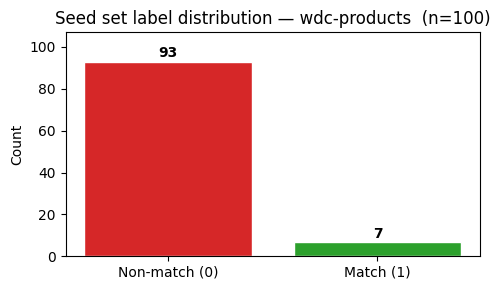

In [19]:
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(["Non-match (0)", "Match (1)"], [n_neg, n_pos],
              color=["#d62728", "#2ca02c"], edgecolor="white")
for bar, val in zip(bars, [n_neg, n_pos]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Count")
ax.set_title(f"Seed set label distribution — {DATASET}  (n={len(df)})")
ax.set_ylim(0, max(n_neg, n_pos) * 1.15)
plt.tight_layout()
plt.show()

## Spot-check: sample matches and non-matches

In [20]:
def trunc(s: str, n: int = 90) -> str:
    # Strip COL/VAL markers for readability
    import re
    s = re.sub(r"COL \w+ VAL ", " | ", s).strip(" |")
    return s[:n] + "…" if len(s) > n else s


for label_val, label_name in [(1, "MATCHES"), (0, "NON-MATCHES")]:
    subset = df[df["label"] == label_val].head(5)
    print(f"\n{'='*70}")
    print(f"  {label_name} (showing up to 5)")
    print(f"{'='*70}")
    for _, row in subset.iterrows():
        print(f"  sim={row.sim_score:.3f}  source={row.source}")
        print(f"  LEFT : {trunc(row.left_text)}")
        print(f"  RIGHT: {trunc(row.right_text)}")
        print(f"  Reason: {row.reasoning}")
        print()


  MATCHES (showing up to 5)
  sim=0.874  source=top
  LEFT : HP 300GB 6G SAS 10K rpm SFF (2.5-inch) SC Enterprise  | HP 300GB 6G SAS 10K rpm SFF (2.5-i…
  RIGHT: HPE 300GB 6G SAS 10K rpm SFF (2.5-inch) SC Enterprise 3yr Warranty HDD  | A 300GB Gen8 SAS…
  Reason: Both listings describe the same HP/HPE 300GB 6G SAS 10K rpm SFF (2.5-inch) SC Enterprise hard drive, with the RIGHT listing simply adding warranty information and a description.

  sim=0.820  source=top
  LEFT : Corsair ML140 Pro LED, Red, 140mm Premium Magnetic Levitation Fan  | Corsair ML140 Pro LED…
  RIGHT: Corsair ML140 PRO LED Rød, 140mm Vifte  | Magnetic Levitation Fan, 140x140x25mm, 400~2000 …
  Reason: Both listings refer to the Corsair ML140 Pro LED in Red, 140mm, with matching specs (400-2000 RPM, 20-97 CFM, 16-37 dBA, 4-pin PWM), just listed in different languages and currencies.

  sim=0.824  source=top
  LEFT : Fujifilm Instax Black Square Film (10 Pack)  | Key FeaturesTo suit FujifilmSqaureInstax Ca…
  RIGHT: i